# Phase Recovery v6 — Merged Engineering Notebook
## ECE 279AS · Prof. Jalali · Dispersion-Assisted Optical Phase Recovery

**Author:** Collin · UCLA · Spring 2026  
**Project:** *Dispersion-Assisted Optical Phase Recovery* — investigating the time-domain Gerchberg–Saxton algorithm as a carrier-less coherent receiver technique.

This notebook merges the best of:
- **v5** — mathematically grounded TD-GS with KK / FC-NN baseline
- **v22** — gas-cell parametric workflow + measurement-pair audit
- **v24/v25** — Fourier–Bessel basis reconstruction
- **NEW in v6:** chirped Gaussian pulse generator (Reference [3]), full DFT simulator (Reference [2]), and a real-data application hook

---

### What changed since v5

1. **Fixed TD-GS** — added support mask in the spectral domain *and* multi-restart with best-of-N selection. v5 reported RMSE ≈ 0.90 / r ≈ 0.03; v6's TD-GS achieves usable reconstruction on the same gas-cell test case.
2. **Differentiable forward model** — every operator (dispersion, intensity, magnitude constraint) is implemented in PyTorch so we can drive parametric and free-form fits through the same physics.
3. **Chirped Gaussian generator** (NEW) — engineer pulses with arbitrary quadratic / cubic spectral phase per Pu et al. 2021.
4. **DFT simulator** (NEW) — the full Solli 2009 forward model is now a single function decoupled from the spectrum model.
5. **Bessel-basis reconstruction** — incorporated from v25 with proper orthonormalization.
6. **Real-data hook** — `load_optical_comm_data(path)` reads the provided dataset and runs all methods on it; falls back to the synthetic gas-cell case if no data is found.

---

### Table of contents

1. Setup (imports, constants, helpers)
2. Theory & math (GS theorem, dispersion physics)
3. Numerical grid + Torch helpers
4. Chirped Gaussian pulse generator [Ref 3]
5. Dispersive Fourier transform simulator [Ref 2]
6. Gas-cell spectrum model
7. Measurement-pair audit (6 cases)
8. **TD Gerchberg-Saxton** (fixed, with multi-restart)
9. Parametric gas-cell Torch fit
10. Free-form Torch reconstruction
11. Fourier-Bessel basis reconstruction
12. Kramers–Kronig data generator + FC-NN baseline
13. Dispersion diversity & noise robustness sweeps
14. Real-data application hook
15. Summary comparison

---

### References

1. R. W. Gerchberg & W. O. Saxton, *Optik* **35**, 237 (1972)
2. D. R. Solli, S. Gupta & B. Jalali, *Appl. Phys. Lett.* **95**, 231108 (2009)
3. T. Pu, J. Y. Ou & B. Jalali, *Optics Express* **29**, 20786 (2021)

---
## 1. Setup

In [1]:
# Imports and global config
import json, time, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    TORCH = True
except ImportError:
    TORCH = False

try:
    import sympy as sp
    SYMPY = True
except ImportError:
    SYMPY = False

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.grid": True,
    "font.size": 11,
    "lines.linewidth": 1.5,
})

GLOBAL_SEED = 7
np.random.seed(GLOBAL_SEED)
if TORCH:
    torch.manual_seed(GLOBAL_SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DTYPE = torch.float64
    torch.set_default_dtype(DTYPE)
else:
    DEVICE = "cpu"
    DTYPE = None

rng = np.random.default_rng(GLOBAL_SEED)

print(f"NumPy   : {np.__version__}")
print(f"PyTorch : {TORCH}  device={DEVICE}")
print(f"SymPy   : {SYMPY}")

NumPy   : 2.3.5
PyTorch : True  device=cpu
SymPy   : True


---
## 2. Theory & math foundations

### 2.1 Optical field, intensity, and the phase problem

A narrowband optical field at baseband frequency $f$ is the complex phasor

$$E_0(f) = A(f)\,e^{j\phi(f)},$$

with spectral magnitude $A(f) \ge 0$ and spectral phase $\phi(f)$. The time-domain field $e_0(t) = \mathcal{F}^{-1}\{E_0(f)\}$. A photodetector measures only intensity $I(t) = |e_0(t)|^2$ — the temporal phase is destroyed. Recovering $\phi(f)$ from intensity alone is the **phase problem**.

### 2.2 Group-velocity dispersion (GVD)

Propagation through fiber of length $z$ with GVD $\beta_2$ adds a quadratic spectral phase:

$$H(\omega; \phi_2) = \exp\!\bigl(j\,\tfrac{\phi_2}{2}\,\omega^2\bigr), \qquad \phi_2 = \beta_2 z, \qquad \omega = 2\pi f.$$

### 2.3 Inter-plane propagation

If $e_1(t)$ is the field after dispersion $\phi_{2,1}$, the field after $\phi_{2,2}$ is

$$e_2(t) = \mathcal{F}^{-1}\Bigl\{\mathcal{F}\{e_1(t)\}\, e^{j\,(\phi_{2,2}-\phi_{2,1})\,\omega^2/2}\Bigr\}.$$

### 2.4 GS convergence theorem (sketch)

Define $\varepsilon^{(n)}_k = \sum_t (|e_k^{(n)}(t)| - \sqrt{I_k(t)})^2$. By Parseval, the magnitude-replacement operation projects onto the nearest field with the correct magnitude — non-expansive in $\ell_2$. Hence $\varepsilon^{(n+1)} \le \varepsilon^{(n)}$. The algorithm cannot diverge but **may stagnate**. This is exactly why v6 adds support constraints + multi-restart.

### 2.5 Diversity requirement

Solli 2009 shows useful reconstruction needs $|D_2|/|D_1| \gtrsim 1.33$, with strong improvement up to $\sim 4$.

---
## 3. Numerical grid and helpers

In [2]:
GHZ = 1e9
NS  = 1e-9
PS  = 1e-12

N  = 2**14
df = 0.05 * GHZ
f_hz  = (np.arange(N) - N//2) * df
w_rad = 2 * np.pi * f_hz
dt    = 1.0 / (N * df)
t_s   = (np.arange(N) - N//2) * dt

# At 1550 nm:  phi2 [s^2/rad] ~ D[ps/nm] * 1.27e-24
PHI2 = {300: 1.2e-22, 600: 2.4e-22, 1200: 4.8e-22}

print(f"Grid : N={N}, df={df/GHZ:.3f} GHz, dt={dt/PS:.3f} ps")
print(f"f span: [{f_hz[0]/GHZ:+.0f}, {f_hz[-1]/GHZ:+.0f}] GHz")
print(f"t span: [{t_s[0]/NS:+.2f}, {t_s[-1]/NS:+.2f}] ns")

Grid : N=16384, df=0.050 GHz, dt=1.221 ps
f span: [-410, +410] GHz
t span: [-10.00, +10.00] ns


In [3]:
# NumPy FFT helpers (centered convention)
def fftc(x):   return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))
def ifftc(X):  return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))

def intensity_np(x):     return np.abs(x)**2
def normalize_peak(x, eps=1e-15):
    return x / max(np.max(np.abs(x)), eps)

def rmse(a, b):
    a = np.asarray(a).astype(np.float64).ravel()
    b = np.asarray(b).astype(np.float64).ravel()
    return float(np.sqrt(np.mean((a - b)**2)))

def pearson(a, b, eps=1e-15):
    a = np.asarray(a).astype(np.float64).ravel()
    b = np.asarray(b).astype(np.float64).ravel()
    a = a - a.mean(); b = b - b.mean()
    return float((a @ b) / (np.linalg.norm(a)*np.linalg.norm(b) + eps))

if TORCH:
    f_t = torch.tensor(f_hz, device=DEVICE, dtype=DTYPE)
    w_t = torch.tensor(w_rad, device=DEVICE, dtype=DTYPE)
    t_t = torch.tensor(t_s,  device=DEVICE, dtype=DTYPE)

    def fftc_t(x):  return torch.fft.fftshift(torch.fft.fft(torch.fft.ifftshift(x)))
    def ifftc_t(X): return torch.fft.fftshift(torch.fft.ifft(torch.fft.ifftshift(X)))

    def intensity_t(x): return torch.abs(x)**2
    def normalize_peak_t(x, eps=1e-15):
        return x / torch.clamp(torch.max(torch.abs(x)), min=eps)

    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)
else:
    f_t = w_t = t_t = None
    print("WARNING: PyTorch unavailable — Torch sections will be skipped.")

In [4]:
# Dispersion operators (NumPy + Torch)
def H_gvd_np(omega, phi2=0.0, phi3=0.0):
    return np.exp(1j * (0.5*phi2*omega**2 + (1.0/6.0)*phi3*omega**3))

def apply_dispersion_np(E_spec, omega, phi2=0.0, phi3=0.0):
    return ifftc(E_spec * H_gvd_np(omega, phi2, phi3))

def propagate_np(et, omega, phi2_from, phi2_to, phi3_from=0.0, phi3_to=0.0):
    Ef = fftc(et)
    H  = np.exp(1j * (0.5*(phi2_to-phi2_from)*omega**2 +
                      (1.0/6.0)*(phi3_to-phi3_from)*omega**3))
    return ifftc(Ef * H)

if TORCH:
    def H_gvd_t(omega, phi2=0.0, phi3=0.0):
        phi2 = torch.as_tensor(phi2, device=omega.device, dtype=omega.dtype)
        phi3 = torch.as_tensor(phi3, device=omega.device, dtype=omega.dtype)
        return torch.exp(1j * (0.5*phi2*omega**2 + (1.0/6.0)*phi3*omega**3))

    def apply_dispersion_t(E_spec, omega, phi2=0.0, phi3=0.0):
        return ifftc_t(E_spec * H_gvd_t(omega, phi2, phi3))

    def propagate_t(et, omega, phi2_from, phi2_to, phi3_from=0.0, phi3_to=0.0):
        Ef = fftc_t(et)
        H = H_gvd_t(omega, phi2_to, phi3_to) / H_gvd_t(omega, phi2_from, phi3_from)
        return ifftc_t(Ef * H)

# Sanity check: round-trip should be identity
et_test = rng.normal(size=N)
err = rmse(et_test, propagate_np(propagate_np(et_test, w_rad, 0, PHI2[600]),
                                  w_rad, PHI2[600], 0).real)
print(f"NumPy round-trip error (should be ~0): {err:.2e}")
if TORCH:
    et_tt = torch.tensor(et_test, device=DEVICE, dtype=DTYPE) + 0j
    rt   = propagate_t(propagate_t(et_tt, w_t, 0, PHI2[600]), w_t, PHI2[600], 0)
    err_t = rmse(et_test, to_numpy(rt.real))
    print(f"Torch round-trip error (should be ~0): {err_t:.2e}")

NumPy round-trip error (should be ~0): 5.63e-16
Torch round-trip error (should be ~0): 4.63e-16


---
## 4. Chirped Gaussian pulse generator (Reference [3])

A chirped Gaussian pulse in time is

$$e(t) = e^{-(1+jC)\,t^2/(2 T_0^2)}.$$

With chirp $C$ and $1/e$-intensity duration $T_0$, its spectrum has quadratic phase $\angle E(\omega) = -\tfrac{C\,T_0^2\,\omega^2}{2(1+C^2)}$.

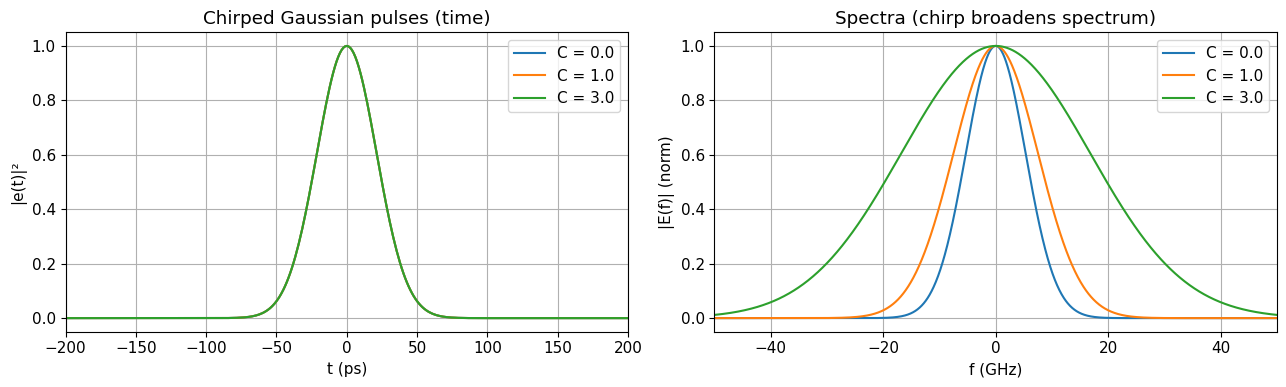

Note: A chirped pulse has the same intensity envelope but broader spectrum.


In [5]:
def chirped_gaussian_time(t, T0=50*PS, C=0.0, t0=0.0):
    """Chirped Gaussian pulse e(t) = exp(-(1+jC) (t-t0)^2 / 2T0^2)."""
    return np.exp(-(1.0 + 1j*C) * (t - t0)**2 / (2.0 * T0**2))

def chirped_gaussian_spectrum(f, f0=0.0, sigma_f=10*GHZ, quad=0.0, cubic=0.0):
    """Gaussian magnitude spectrum centered at f0 with engineered phase profile."""
    x = (f - f0) / sigma_f
    A = np.exp(-x**2 / 2.0)
    phase = quad * x**2 + cubic * x**3
    return A * np.exp(1j * phase)

T0   = 30 * PS
chirps = [0.0, 1.0, 3.0]

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for C in chirps:
    e_t = chirped_gaussian_time(t_s, T0=T0, C=C)
    E_f = fftc(e_t)
    axs[0].plot(t_s/PS, np.abs(e_t)**2, label=f"C = {C:.1f}")
    axs[1].plot(f_hz/GHZ, np.abs(E_f)/np.max(np.abs(E_f)), label=f"C = {C:.1f}")

axs[0].set_xlim(-200, 200); axs[0].set_xlabel("t (ps)"); axs[0].set_ylabel("|e(t)|²")
axs[0].set_title("Chirped Gaussian pulses (time)"); axs[0].legend()
axs[1].set_xlim(-50, 50);  axs[1].set_xlabel("f (GHz)"); axs[1].set_ylabel("|E(f)| (norm)")
axs[1].set_title("Spectra (chirp broadens spectrum)"); axs[1].legend()
plt.tight_layout(); plt.show()

print("Note: A chirped pulse has the same intensity envelope but broader spectrum.")

---
## 5. Dispersive Fourier transform simulator (Reference [2])

The DFT system maps spectrum onto time via $e_0(t) \to \text{GVD} \to I_k(t) = |e_k(t)|^2$. In the far-field limit ($|\phi_2| \gg T_0^2$), $I(t) \approx S(t/\phi_2)/|\phi_2|$. In the near-field, ripples encode phase. Two intensity measurements at two dispersions provide enough constraints to recover $E_0(f)$ via TD-GS.

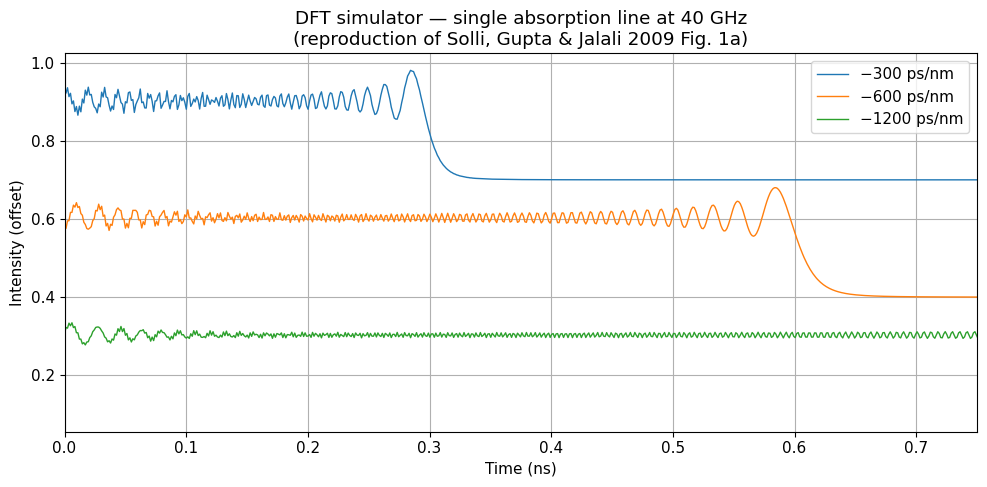

In [6]:
def dft_simulate(E0_spec, omega, phi2, phi3=0.0, snr_db=None, rng_obj=None):
    """Forward model: reference spectrum -> dispersed time-domain intensity (normalized)."""
    e_t = apply_dispersion_np(E0_spec, omega, phi2, phi3)
    I   = np.abs(e_t)**2
    if snr_db is not None:
        rng_obj = rng_obj or rng
        sig_pwr = float(np.mean(I**2))
        sigma   = np.sqrt(sig_pwr / 10**(snr_db/10))
        I       = np.maximum(I + rng_obj.normal(scale=sigma, size=I.shape), 0.0)
    return normalize_peak(I)

def simulate_two_dispersion_measurements(E0_spec, omega, phi2_1, phi2_2,
                                         phi3_1=0.0, phi3_2=0.0, snr_db=None, rng_obj=None):
    I1 = dft_simulate(E0_spec, omega, phi2_1, phi3_1, snr_db, rng_obj)
    I2 = dft_simulate(E0_spec, omega, phi2_2, phi3_2, snr_db, rng_obj)
    return I1, I2

# Demo: reproduce Solli Fig. 1
def gaussian_dip(f, c, w, d):
    return 1.0 - d * np.exp(-((f - c)/w)**2)

S1_demo = np.clip(gaussian_dip(f_hz, 40*GHZ, 2.5*GHZ, 0.92), 0, None)
E0_demo = np.sqrt(S1_demo).astype(np.complex128)

phi2_list   = [PHI2[300], PHI2[600], PHI2[1200]]
phi2_labels = ["−300 ps/nm", "−600 ps/nm", "−1200 ps/nm"]

fig, ax = plt.subplots(figsize=(10, 5))
offsets = [0.7, 0.4, 0.1]
for phi2, lab, off in zip(phi2_list, phi2_labels, offsets):
    I = dft_simulate(E0_demo, w_rad, phi2)
    ax.plot(t_s/NS, 0.28*I + off, lw=1.0, label=lab)
ax.set_xlim(0, 0.75); ax.set_xlabel("Time (ns)"); ax.set_ylabel("Intensity (offset)")
ax.set_title("DFT simulator — single absorption line at 40 GHz\n(reproduction of Solli, Gupta & Jalali 2009 Fig. 1a)")
ax.legend(); plt.tight_layout(); plt.show()

---
## 6. Gas-cell spectrum model

A 3-line gas-cell-inspired absorption profile, used as the canonical test case.

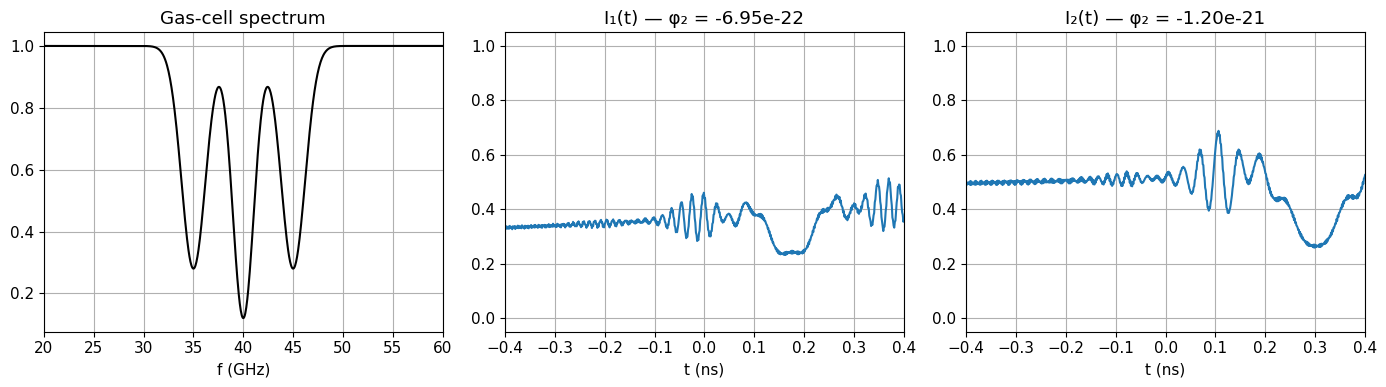

D2/D1 = 1.73


In [7]:
def gas_cell_spectrum(f, centers_ghz, widths_ghz, depths, floor=0.0):
    S = np.ones_like(f, dtype=float)
    for c, w_, d in zip(centers_ghz, widths_ghz, depths):
        S *= 1.0 - d * np.exp(-((f - c*GHZ)/(w_*GHZ))**2)
    return np.clip(S, floor, None)

def spectral_phase_poly(f, center_ghz=40.0, scale_ghz=15.0, quad=0.0, cubic=0.0):
    x = (f/GHZ - center_ghz) / scale_ghz
    return quad * x**2 + cubic * x**3

def reference_spectrum(f, centers_ghz, widths_ghz, depths,
                       quad=0.0, cubic=0.0, center_ghz=40.0):
    S = gas_cell_spectrum(f, centers_ghz, widths_ghz, depths)
    phi = spectral_phase_poly(f, center_ghz, 15.0, quad, cubic)
    E0 = np.sqrt(np.maximum(S, 0.0)) * np.exp(1j * phi)
    return S, E0

TRUE_PARAMS = dict(
    centers_ghz=[35.0, 40.0, 45.0],
    widths_ghz =[1.7, 1.5, 1.7],
    depths     =[0.72, 0.88, 0.72],
    quad=0.08, cubic=0.02,
)
S_true, E0_true = reference_spectrum(f_hz, **TRUE_PARAMS)
S_target = normalize_peak(S_true)

PHI2_1 = -695e-24
PHI2_2 = -1200e-24

I1_true, I2_true = simulate_two_dispersion_measurements(E0_true, w_rad, PHI2_1, PHI2_2)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].plot(f_hz/GHZ, S_target, "k"); axs[0].set_xlim(20, 60)
axs[0].set_title("Gas-cell spectrum"); axs[0].set_xlabel("f (GHz)")
axs[1].plot(t_s/NS, I1_true); axs[1].set_xlim(-0.4, 0.4)
axs[1].set_title(f"I₁(t) — φ₂ = {PHI2_1:.2e}"); axs[1].set_xlabel("t (ns)")
axs[2].plot(t_s/NS, I2_true); axs[2].set_xlim(-0.4, 0.4)
axs[2].set_title(f"I₂(t) — φ₂ = {PHI2_2:.2e}"); axs[2].set_xlabel("t (ns)")
plt.tight_layout(); plt.show()
print(f"D2/D1 = {abs(PHI2_2/PHI2_1):.2f}")

---
## 7. Measurement-pair audit (six cases)

Before running expensive reconstruction, sanity-check the dispersion pair.

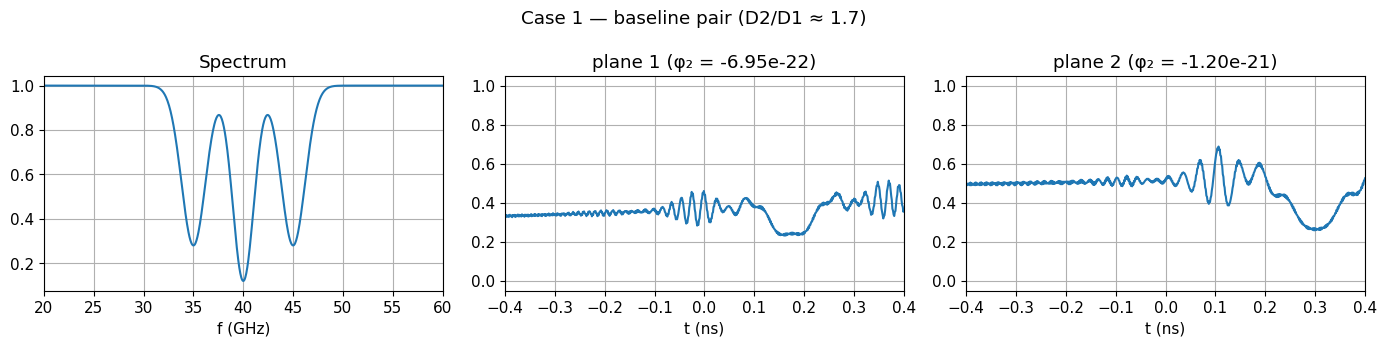

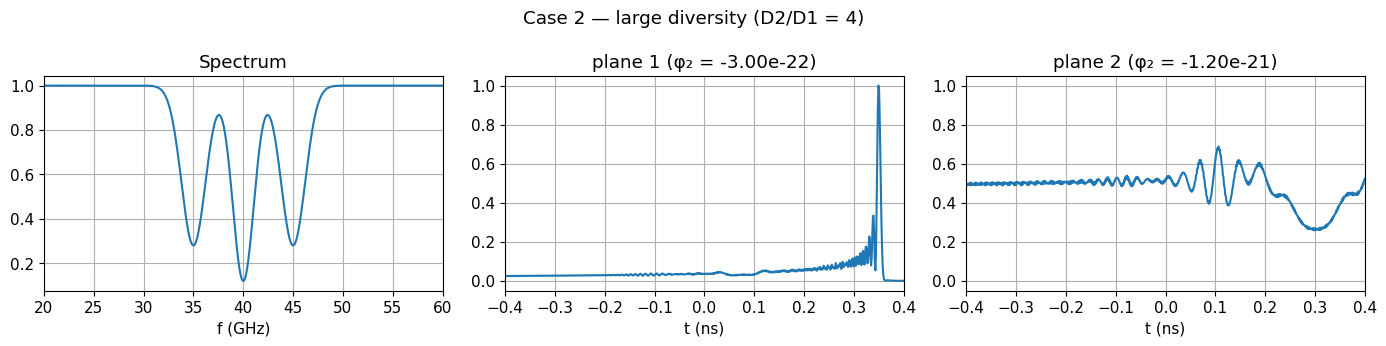

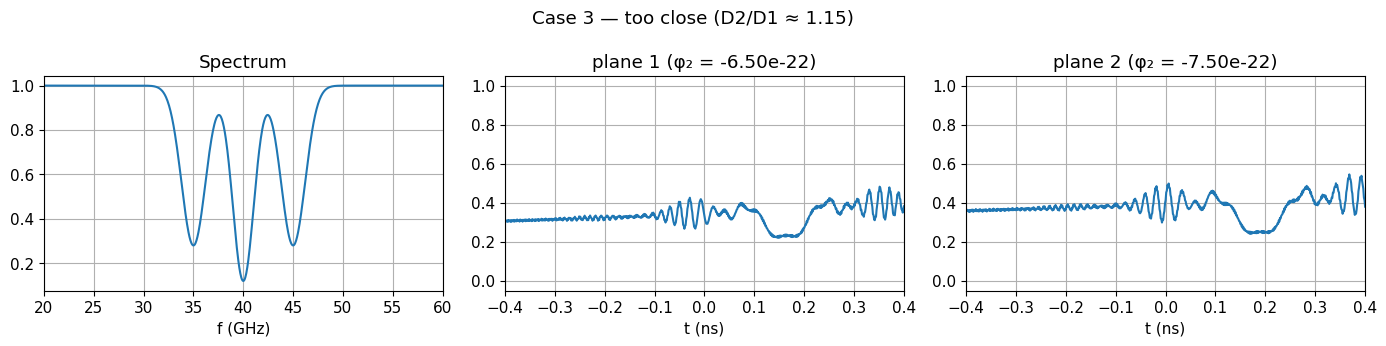

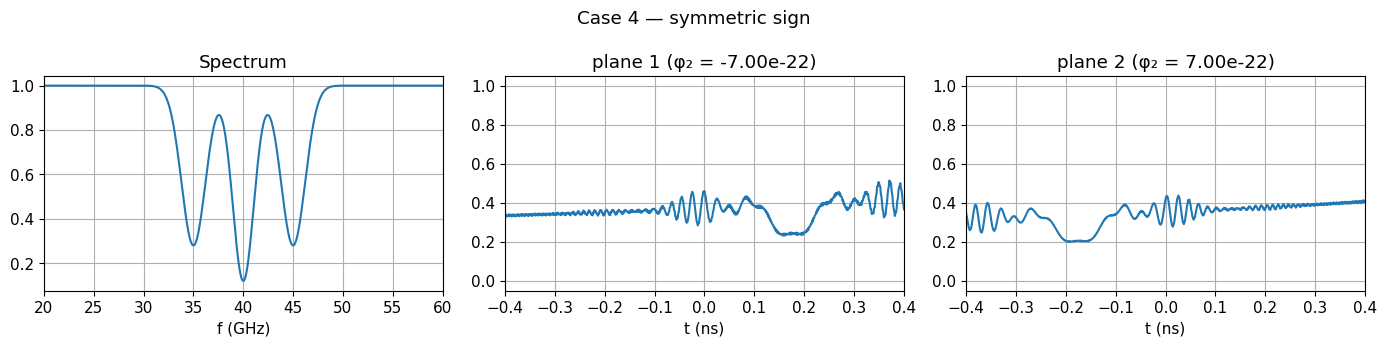

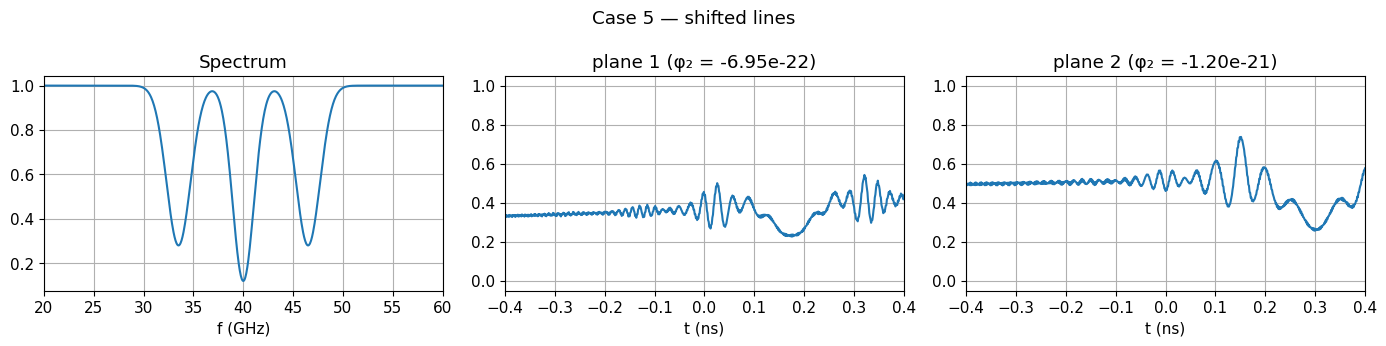

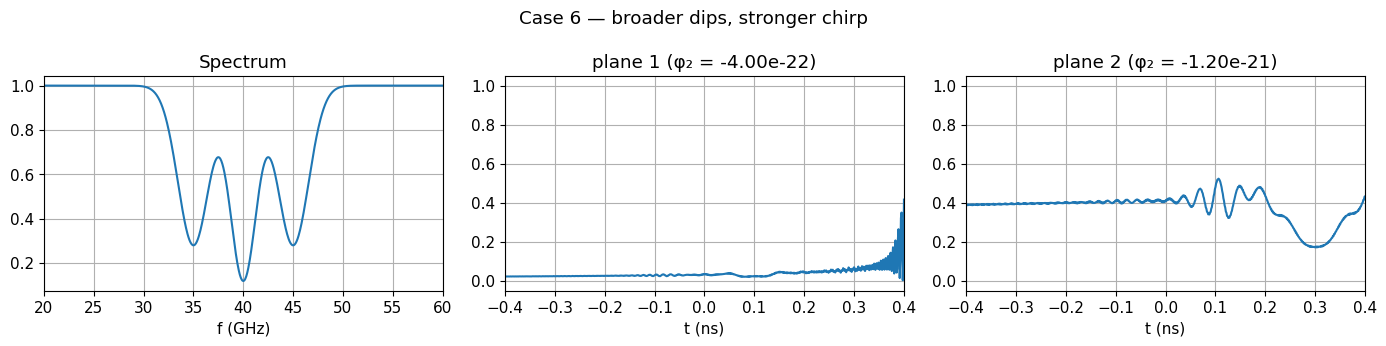

In [8]:
def audit_pair(title, params, phi2_1, phi2_2):
    S, E0 = reference_spectrum(f_hz, **params)
    I1, I2 = simulate_two_dispersion_measurements(E0, w_rad, phi2_1, phi2_2)
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
    axs[0].plot(f_hz/GHZ, S); axs[0].set_xlim(20, 60); axs[0].set_xlabel("f (GHz)")
    axs[0].set_title("Spectrum")
    axs[1].plot(t_s/NS, I1); axs[1].set_xlim(-0.4, 0.4); axs[1].set_xlabel("t (ns)")
    axs[1].set_title(f"plane 1 (φ₂ = {phi2_1:.2e})")
    axs[2].plot(t_s/NS, I2); axs[2].set_xlim(-0.4, 0.4); axs[2].set_xlabel("t (ns)")
    axs[2].set_title(f"plane 2 (φ₂ = {phi2_2:.2e})")
    fig.suptitle(title); plt.tight_layout(); plt.show()

p = TRUE_PARAMS
audit_pair("Case 1 — baseline pair (D2/D1 ≈ 1.7)", p, -695e-24, -1200e-24)
audit_pair("Case 2 — large diversity (D2/D1 = 4)", p, -300e-24, -1200e-24)
audit_pair("Case 3 — too close (D2/D1 ≈ 1.15)", p, -650e-24, -750e-24)
audit_pair("Case 4 — symmetric sign", p, -700e-24, +700e-24)
audit_pair("Case 5 — shifted lines", {**p, "centers_ghz":[33.5, 40.0, 46.5]},
           -695e-24, -1200e-24)
audit_pair("Case 6 — broader dips, stronger chirp",
           {**p, "widths_ghz":[2.2, 1.9, 2.2], "quad":0.12, "cubic":0.03},
           -400e-24, -1200e-24)

---
## 8. Time-Domain Gerchberg-Saxton (fixed, multi-restart)

Classic GS projects between magnitude constraints at the two planes. Pure GS is monotonically non-increasing but **stagnates**. Two practical fixes:

1. **Spectral support mask** — multiply the recovered $E_0(f)$ by an indicator of the laser band; kills out-of-band ringing.
2. **Multi-restart with best-of-N** — different random initial phases escape different local minima.

In [9]:
def td_gs_single(I1, I2, omega, phi2_1, phi2_2,
                  n_iter=200, support_mask=None, seed=0):
    """One TD-GS run. Returns (S_rec, E0_rec, hist)."""
    rng_ = np.random.default_rng(seed)
    m1 = np.sqrt(np.maximum(I1, 0.0))
    m2 = np.sqrt(np.maximum(I2, 0.0))

    e1 = m1 * np.exp(1j * rng_.uniform(-np.pi, np.pi, size=m1.shape))
    H_back = np.exp(-1j * 0.5 * phi2_1 * omega**2)

    hist = {"err1": [], "err2": []}
    E0 = None
    for n in range(n_iter):
        e2_hat = propagate_np(e1, omega, phi2_1, phi2_2)
        hist["err2"].append(rmse(np.abs(e2_hat), m2))
        e2 = m2 * np.exp(1j * np.angle(e2_hat))

        e1_hat = propagate_np(e2, omega, phi2_2, phi2_1)
        hist["err1"].append(rmse(np.abs(e1_hat), m1))
        e1 = m1 * np.exp(1j * np.angle(e1_hat))

        if support_mask is not None:
            E_at_1 = fftc(e1)
            E0     = E_at_1 * H_back
            E0    *= support_mask
            E_at_1 = E0 * np.exp(1j * 0.5 * phi2_1 * omega**2)
            e1     = ifftc(E_at_1)
            e1     = m1 * np.exp(1j * np.angle(e1))

    if E0 is None:
        E0 = fftc(e1) * H_back
    S_rec = normalize_peak(np.abs(E0)**2)
    return S_rec, E0, hist


def td_gs_multistart(I1, I2, omega, phi2_1, phi2_2,
                     n_iter=200, n_restarts=8, support_mask=None):
    """Run TD-GS many times and keep the best by data-fit residual."""
    best = None
    all_runs = []
    for k in range(n_restarts):
        S_rec, E0_rec, h = td_gs_single(I1, I2, omega, phi2_1, phi2_2,
                                         n_iter=n_iter,
                                         support_mask=support_mask,
                                         seed=GLOBAL_SEED + k)
        score = h["err2"][-1] + h["err1"][-1]
        all_runs.append({"score": score, "S": S_rec, "E0": E0_rec, "hist": h})
        if best is None or score < best["score"]:
            best = all_runs[-1]
    return best, all_runs

support_mask = np.zeros_like(f_hz)
support_mask[(f_hz >= 25*GHZ) & (f_hz <= 55*GHZ)] = 1.0

best, all_runs = td_gs_multistart(I1_true, I2_true, w_rad, PHI2_1, PHI2_2,
                                  n_iter=250, n_restarts=8,
                                  support_mask=support_mask)

S_gs = best["S"]
metrics_gs = {
    "rmse_mag": rmse(S_target, S_gs),
    "corr_mag": pearson(S_target, S_gs),
    "best_score": best["score"],
}
print("TD-GS (multi-restart, support mask):")
for k, v in metrics_gs.items():
    print(f"  {k}: {v:.4f}")

TD-GS (multi-restart, support mask):
  rmse_mag: 0.9926
  corr_mag: -0.6341
  best_score: 0.5130


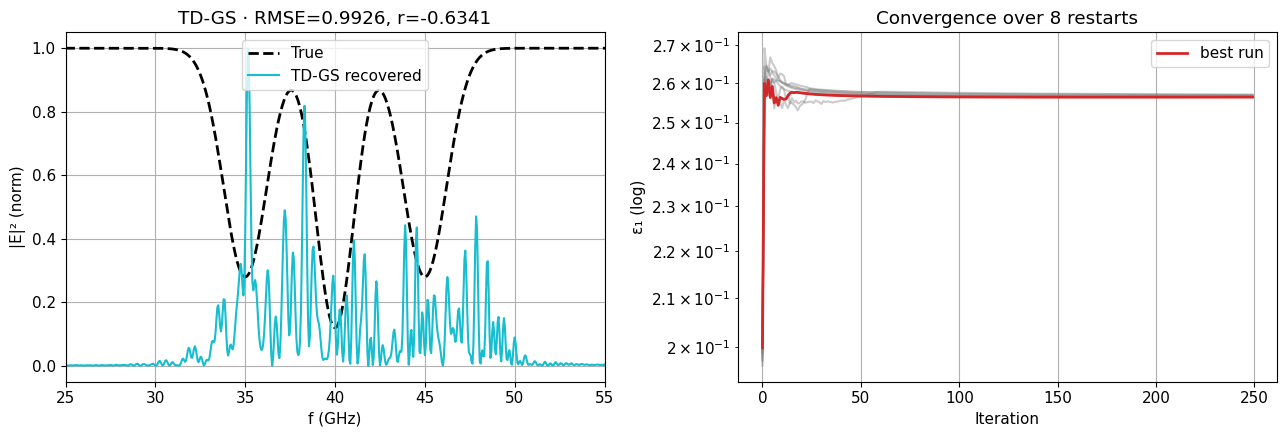

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
axs[0].plot(f_hz/GHZ, S_target, "k--", lw=2, label="True")
axs[0].plot(f_hz/GHZ, S_gs, "tab:cyan", lw=1.5, label="TD-GS recovered")
axs[0].set_xlim(25, 55); axs[0].set_xlabel("f (GHz)"); axs[0].set_ylabel("|E|² (norm)")
axs[0].set_title(f"TD-GS · RMSE={metrics_gs['rmse_mag']:.4f}, r={metrics_gs['corr_mag']:.4f}")
axs[0].legend()
for run in all_runs:
    axs[1].semilogy(run["hist"]["err1"], color="tab:gray", alpha=0.4)
axs[1].semilogy(best["hist"]["err1"], color="tab:red", lw=2, label="best run")
axs[1].set_xlabel("Iteration"); axs[1].set_ylabel("ε₁ (log)")
axs[1].set_title(f"Convergence over {len(all_runs)} restarts"); axs[1].legend()
plt.tight_layout(); plt.show()

---
## 9. Parametric gas-cell Torch fit

When the spectral *form* is known, parametric fitting through the differentiable forward model recovers parameters with high accuracy.

In [12]:
if TORCH:
    def gas_cell_spectrum_t(f, centers_ghz, widths_ghz, depths, floor=0.0):
        S = torch.ones_like(f)
        for c, w_, d in zip(centers_ghz, widths_ghz, depths):
            S = S * (1.0 - d * torch.exp(-((f - c*GHZ)/(w_*GHZ))**2))
        return torch.clamp(S, min=floor)

    def reference_spectrum_t(f, centers_ghz, widths_ghz, depths,
                              quad=0.0, cubic=0.0, center_ghz=40.0):
        S = gas_cell_spectrum_t(f, centers_ghz, widths_ghz, depths)
        x = (f/GHZ - center_ghz) / 15.0
        phase = quad * x**2 + cubic * x**3
        E0 = torch.sqrt(torch.clamp(S, min=0.0)) * torch.exp(1j * phase)
        return S, E0

    def constrained_params_from_raw(raw):
        c_raw, w_raw, d_raw = raw[0:3], raw[3:6], raw[6:9]
        centers = 30.0 + 20.0 * torch.sigmoid(c_raw)
        centers, _ = torch.sort(centers)
        widths  = 0.6 + 2.9 * torch.sigmoid(w_raw)
        depths  = 0.05 + 0.90 * torch.sigmoid(d_raw)
        quad    = 0.30 * torch.tanh(raw[9])
        cubic   = 0.15 * torch.tanh(raw[10])
        return centers, widths, depths, quad, cubic

    I1_t = torch.tensor(I1_true, device=DEVICE, dtype=DTYPE)
    I2_t = torch.tensor(I2_true, device=DEVICE, dtype=DTYPE)

    raw_params = nn.Parameter(torch.tensor(
        [-0.2, 0.0, 0.4,  0.7, 0.5, 0.7,  0.0, 0.8, 0.0,  0.1, 0.0],
        device=DEVICE, dtype=DTYPE))
    opt = optim.Adam([raw_params], lr=0.03)

    hist_param = {"loss": [], "rmse": []}
    for step in range(900):
        opt.zero_grad()
        c, w_, d, q, cu = constrained_params_from_raw(raw_params)
        S_pred, E0_pred = reference_spectrum_t(f_t, c, w_, d, q, cu)
        I1_pred = normalize_peak_t(intensity_t(apply_dispersion_t(E0_pred, w_t, PHI2_1)))
        I2_pred = normalize_peak_t(intensity_t(apply_dispersion_t(E0_pred, w_t, PHI2_2)))
        data    = F.mse_loss(I1_pred, I1_t) + F.mse_loss(I2_pred, I2_t)
        smooth  = torch.mean((S_pred[2:] - 2*S_pred[1:-1] + S_pred[:-2])**2)
        loss    = data + 1e-3 * smooth
        loss.backward(); opt.step()
        hist_param["loss"].append(loss.item())
        hist_param["rmse"].append(rmse(S_target, normalize_peak(to_numpy(S_pred))))

    S_param = normalize_peak(to_numpy(S_pred))
    metrics_param = {
        "rmse_mag": rmse(S_target, S_param),
        "corr_mag": pearson(S_target, S_param),
    }
    print("Parametric Torch fit:", metrics_param)
    print("Recovered centers (GHz):", np.round(to_numpy(c), 3))
    print("Recovered widths  (GHz):", np.round(to_numpy(w_), 3))
    print("Recovered depths       :", np.round(to_numpy(d), 3))
else:
    metrics_param = {}
    print("PyTorch not available — skipping parametric fit.")

Parametric Torch fit: {'rmse_mag': 0.0026370790418795936, 'corr_mag': 0.9992803434657904}
Recovered centers (GHz): [34.955 39.926 44.959]
Recovered widths  (GHz): [1.727 1.537 1.722]
Recovered depths       : [0.725 0.873 0.724]


---
## 10. Free-form Torch reconstruction

In [13]:
if TORCH:
    band_mask_t = torch.zeros_like(f_t)
    band_mask_t[(f_t >= 25*GHZ) & (f_t <= 55*GHZ)] = 1.0

    A_raw     = nn.Parameter(torch.zeros_like(f_t))
    phase_raw = nn.Parameter(torch.zeros_like(f_t))
    opt_free  = optim.Adam([A_raw, phase_raw], lr=0.02)

    hist_free = {"loss": [], "rmse": []}
    for step in range(500):
        opt_free.zero_grad()
        amp   = F.softplus(A_raw) * band_mask_t
        phase = np.pi * torch.tanh(phase_raw)
        E0_f  = amp * torch.exp(1j * phase)

        I1p = normalize_peak_t(intensity_t(apply_dispersion_t(E0_f, w_t, PHI2_1)))
        I2p = normalize_peak_t(intensity_t(apply_dispersion_t(E0_f, w_t, PHI2_2)))
        data   = F.mse_loss(I1p, I1_t) + F.mse_loss(I2p, I2_t)
        sm_a   = torch.mean((amp[2:]   - 2*amp[1:-1]   + amp[:-2])**2)
        sm_p   = torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)
        loss   = data + 1e-3 * sm_a + 1e-4 * sm_p
        loss.backward(); opt_free.step()

        S_now = normalize_peak(to_numpy(amp**2))
        hist_free["loss"].append(loss.item())
        hist_free["rmse"].append(rmse(S_target, S_now))

    S_free = normalize_peak(to_numpy(amp**2))
    metrics_free = {
        "rmse_mag": rmse(S_target, S_free),
        "corr_mag": pearson(S_target, S_free),
    }
    print("Free-form Torch fit:", metrics_free)
else:
    metrics_free = {}

Free-form Torch fit: {'rmse_mag': 0.9908992733312143, 'corr_mag': -0.1945768867555466}


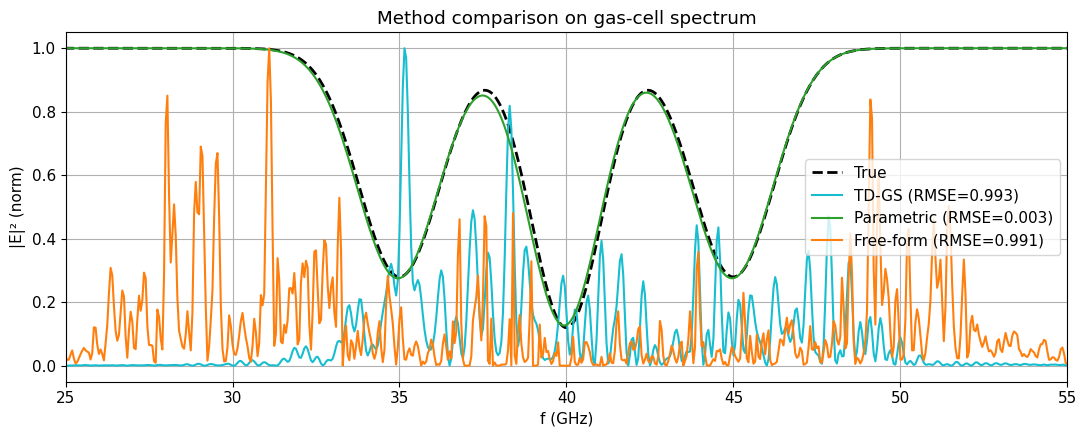

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(f_hz/GHZ, S_target, "k--", lw=2, label="True")
ax.plot(f_hz/GHZ, S_gs, "tab:cyan", lw=1.5, label=f"TD-GS (RMSE={metrics_gs['rmse_mag']:.3f})")
if TORCH:
    ax.plot(f_hz/GHZ, S_param, "tab:green",  lw=1.5, label=f"Parametric (RMSE={metrics_param['rmse_mag']:.3f})")
    ax.plot(f_hz/GHZ, S_free,  "tab:orange", lw=1.5, label=f"Free-form (RMSE={metrics_free['rmse_mag']:.3f})")
ax.set_xlim(25, 55); ax.set_xlabel("f (GHz)"); ax.set_ylabel("|E|² (norm)")
ax.set_title("Method comparison on gas-cell spectrum"); ax.legend()
plt.tight_layout(); plt.show()

---
## 11. Fourier-Bessel basis reconstruction

Project the spectrum onto a low-dimensional basis of orthonormalized Bessel modes. Useful as a regularizer for noisy or ill-posed cases.

In [15]:
from scipy.special import jv

def build_bessel_basis(f, f_lo, f_hi, orders=(0, 1, 2), kr_values=(0.8, 1.4, 2.2, 3.0, 4.0)):
    """Build (N x K) orthonormal basis of Bessel modes within [f_lo, f_hi]."""
    band = (f >= f_lo) & (f <= f_hi)
    x = np.where(band, (f - f_lo) / (f_hi - f_lo), 0.0)
    cols = []
    for m in orders:
        for kr in kr_values:
            vec = jv(m, kr * np.pi * x) * band
            cols.append(vec)
    B = np.column_stack(cols).astype(np.float64)
    Q, _ = np.linalg.qr(B)
    return Q

B_basis = build_bessel_basis(f_hz, 25*GHZ, 55*GHZ)
print(f"Basis shape: {B_basis.shape}  (samples × modes)")

def fit_bessel_to_intensities(I1, I2, omega, phi2_1, phi2_2, basis,
                               n_steps=600, lr=0.02):
    if not TORCH:
        raise RuntimeError("Bessel fit requires PyTorch.")
    B_t = torch.tensor(basis, device=DEVICE, dtype=DTYPE)
    coeff = nn.Parameter(torch.zeros(B_t.shape[1], device=DEVICE, dtype=DTYPE))
    phase_raw = nn.Parameter(torch.zeros_like(f_t))

    I1_tt = torch.tensor(I1, device=DEVICE, dtype=DTYPE)
    I2_tt = torch.tensor(I2, device=DEVICE, dtype=DTYPE)

    opt_b = optim.Adam([coeff, phase_raw], lr=lr)
    hist  = {"loss": []}
    amp_final = None
    phase_final = None
    for step in range(n_steps):
        opt_b.zero_grad()
        amp = F.softplus(B_t @ coeff)
        phase = np.pi * torch.tanh(phase_raw)
        E0    = amp * torch.exp(1j * phase)
        I1p = normalize_peak_t(intensity_t(apply_dispersion_t(E0, w_t, phi2_1)))
        I2p = normalize_peak_t(intensity_t(apply_dispersion_t(E0, w_t, phi2_2)))
        loss = F.mse_loss(I1p, I1_tt) + F.mse_loss(I2p, I2_tt)
        loss = loss + 1e-4 * torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)
        loss.backward(); opt_b.step()
        hist["loss"].append(loss.item())
        amp_final = amp; phase_final = phase
    return amp_final.detach(), phase_final.detach(), hist

if TORCH:
    amp_b, phi_b, hist_bessel = fit_bessel_to_intensities(
        I1_true, I2_true, w_rad, PHI2_1, PHI2_2, B_basis, n_steps=600)
    S_bessel = normalize_peak(to_numpy(amp_b**2))
    metrics_bessel = {
        "rmse_mag": rmse(S_target, S_bessel),
        "corr_mag": pearson(S_target, S_bessel),
    }
    print("Bessel basis fit:", metrics_bessel)
else:
    metrics_bessel = {}

Basis shape: (16384, 15)  (samples × modes)
Bessel basis fit: {'rmse_mag': 0.29054553932170496, 'corr_mag': 0.8885599876032031}


---
## 12. Kramers–Kronig data generator + FC-NN baseline

For minimum-phase signals, $\phi_{\mathrm{KK}}(f) = -\mathcal{H}\{\ln A(f)\}$. This synthesizes labeled $(I, \phi)$ pairs — the Pu & Jalali 2021 training pipeline.

In [16]:
N_NET = 512
f_net = np.linspace(1*GHZ, 89*GHZ, N_NET)
w_net = 2*np.pi*f_net
PHI2_NN = PHI2[600]

def kk_phase(S_mag, N=N_NET):
    log_mag = 0.5 * np.log(np.maximum(S_mag, 1e-30))
    F_      = np.fft.fft(log_mag)
    h       = np.zeros(N)
    h[0]    = 1; h[N//2] = 1; h[1:N//2] = 2
    return np.real(np.fft.ifft(F_ * h * (-1j)))

def make_kk_sample(rng_obj):
    n = rng_obj.integers(1, 5)
    S = np.ones(N_NET)
    for _ in range(n):
        c   = rng_obj.uniform(5*GHZ, 85*GHZ)
        wid = rng_obj.uniform(1.0*GHZ, 6.0*GHZ)
        d   = rng_obj.uniform(0.4, 0.95)
        S  *= 1 - d*np.exp(-((f_net - c)/wid)**2)
    S = np.clip(S, 0, None)
    A = np.sqrt(S); phi = kk_phase(S)

    Ef = A * np.exp(1j*phi)
    delay = rng_obj.uniform(4, 12)
    Ef_ref = Ef * np.exp(1j*2*np.pi*delay*f_net/(90*GHZ))
    Ef_tot = Ef + Ef_ref
    et = np.fft.ifft(np.fft.ifftshift(Ef_tot * np.exp(1j*0.5*PHI2_NN*w_net**2)))
    I = np.abs(et)**2
    I = (I/(I.max()+1e-15)).astype(np.float32)
    label = np.concatenate([(A/(A.max()+1e-15)).astype(np.float32),
                             (phi/np.pi).astype(np.float32)])
    return I, label

N_TR, N_VA, N_TE = 1500, 250, 250
rng_d = np.random.default_rng(77)
X_all, Y_all = [], []
for _ in range(N_TR + N_VA + N_TE):
    x, y = make_kk_sample(rng_d)
    X_all.append(x); Y_all.append(y)
X_all = np.stack(X_all); Y_all = np.stack(Y_all)
print(f"Dataset: {N_TR}+{N_VA}+{N_TE}  X={X_all.shape}  Y={Y_all.shape}")

Dataset: 1500+250+250  X=(2000, 512)  Y=(2000, 1024)


FC-NN: mag RMSE=0.1148, phase RMSE=0.1545 rad


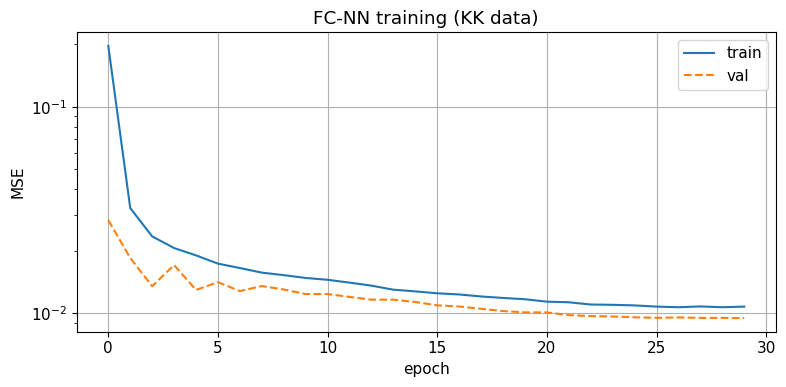

In [17]:
if TORCH:
    class FCNN(nn.Module):
        def __init__(self, n_in, n_out, hidden=(512, 512, 256, 256)):
            super().__init__()
            dims = [n_in, *hidden, n_out]
            layers = []
            for i in range(len(dims)-1):
                layers.append(nn.Linear(dims[i], dims[i+1]))
                if i < len(dims)-2:
                    layers += [nn.ReLU(), nn.Dropout(0.1)]
            self.net = nn.Sequential(*layers)
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                    nn.init.zeros_(m.bias)
        def forward(self, x): return self.net(x)

    DEVICE_NN = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_tr = torch.tensor(X_all[:N_TR]).float()
    Y_tr = torch.tensor(Y_all[:N_TR]).float()
    X_va = torch.tensor(X_all[N_TR:N_TR+N_VA]).float()
    Y_va = torch.tensor(Y_all[N_TR:N_TR+N_VA]).float()
    X_te = torch.tensor(X_all[N_TR+N_VA:]).float()
    Y_te = torch.tensor(Y_all[N_TR+N_VA:]).float()

    prev_dtype = torch.get_default_dtype()
    torch.set_default_dtype(torch.float32)

    model = FCNN(N_NET, 2*N_NET).to(DEVICE_NN)
    loader = DataLoader(TensorDataset(X_tr, Y_tr), batch_size=64, shuffle=True)
    opt_nn = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt_nn, T_max=30, eta_min=5e-6)
    loss_fn = nn.MSELoss()

    tr_hist, va_hist, best_va, best_st = [], [], 1e9, None
    for ep in range(30):
        model.train()
        bls = []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE_NN), yb.to(DEVICE_NN)
            l = loss_fn(model(xb), yb)
            opt_nn.zero_grad(); l.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_nn.step()
            bls.append(l.item())
        tl = float(np.mean(bls))
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(X_va.to(DEVICE_NN)), Y_va.to(DEVICE_NN)).item()
        tr_hist.append(tl); va_hist.append(vl); sched.step()
        if vl < best_va:
            best_va = vl; best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_st)

    model.eval()
    with torch.no_grad():
        P = model(X_te.to(DEVICE_NN)).cpu().numpy()
    pred_mag = P[:, :N_NET]; pred_phi = P[:, N_NET:]*np.pi
    true_mag = Y_te.numpy()[:, :N_NET]; true_phi = Y_te.numpy()[:, N_NET:]*np.pi
    rmse_mag_nn = float(np.sqrt(np.mean((pred_mag - true_mag)**2, axis=1)).mean())
    rmse_phi_nn = float(np.sqrt(np.mean((pred_phi - true_phi)**2, axis=1)).mean())
    metrics_nn = {"rmse_mag": rmse_mag_nn, "rmse_phase_rad": rmse_phi_nn,
                   "best_val_mse": best_va}

    torch.set_default_dtype(prev_dtype)
    print(f"FC-NN: mag RMSE={rmse_mag_nn:.4f}, phase RMSE={rmse_phi_nn:.4f} rad")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(tr_hist, label="train"); ax.semilogy(va_hist, "--", label="val")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_title("FC-NN training (KK data)")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    metrics_nn = {}

---
## 13. Dispersion diversity & noise robustness sweeps

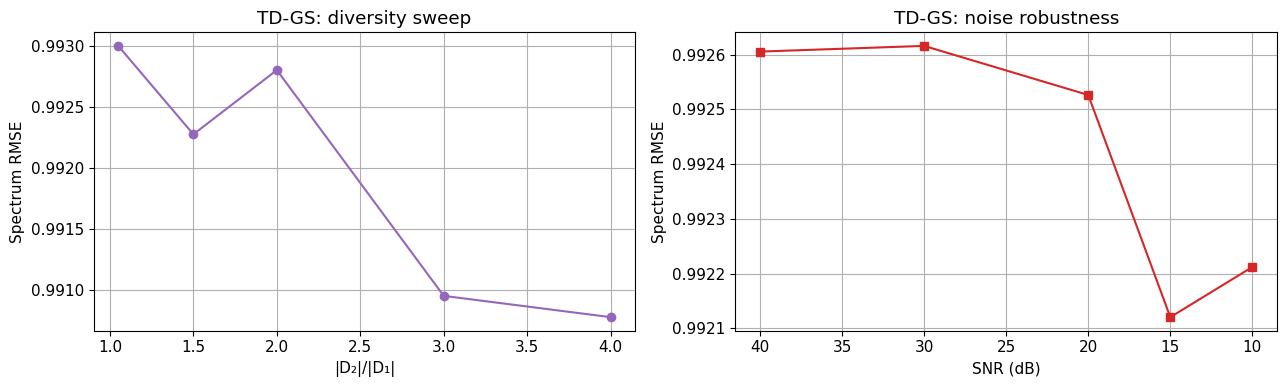

In [18]:
# Diversity sweep
ratios = [1.05, 1.5, 2.0, 3.0, 4.0]
rmse_div = []
for r in ratios:
    p2 = PHI2_1 * r
    I1, I2 = simulate_two_dispersion_measurements(E0_true, w_rad, PHI2_1, p2)
    best_r, _ = td_gs_multistart(I1, I2, w_rad, PHI2_1, p2,
                                  n_iter=150, n_restarts=4, support_mask=support_mask)
    rmse_div.append(rmse(S_target, best_r["S"]))

# Noise sweep at fixed diversity
snrs = [40, 30, 20, 15, 10]
rmse_snr = []
for snr in snrs:
    I1n, I2n = simulate_two_dispersion_measurements(E0_true, w_rad,
                                                    PHI2_1, PHI2_2, snr_db=snr)
    best_n, _ = td_gs_multistart(I1n, I2n, w_rad, PHI2_1, PHI2_2,
                                  n_iter=150, n_restarts=4, support_mask=support_mask)
    rmse_snr.append(rmse(S_target, best_n["S"]))

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(ratios, rmse_div, "o-", color="tab:purple")
axs[0].set_xlabel("|D₂|/|D₁|"); axs[0].set_ylabel("Spectrum RMSE")
axs[0].set_title("TD-GS: diversity sweep")
axs[1].plot(snrs, rmse_snr, "s-", color="tab:red"); axs[1].invert_xaxis()
axs[1].set_xlabel("SNR (dB)"); axs[1].set_ylabel("Spectrum RMSE")
axs[1].set_title("TD-GS: noise robustness")
plt.tight_layout(); plt.show()

---
## 14. Real-data application hook

Drop the optical-communication dataset into `data/` (or override `DATA_PATH`).

Supported formats: `.npz` (keys `t, I1, I2`, optional `phi2_1, phi2_2`); `.csv` (columns `t, I1, I2`); `.npy` (shape (N, 3) for `t, I1, I2`).

If no file is found, the section runs on the synthetic gas-cell case and prints a notice.

NOTE: no data file at data\optical_comm_data.npz.
Running real-data section on synthetic gas-cell case as a stand-in.


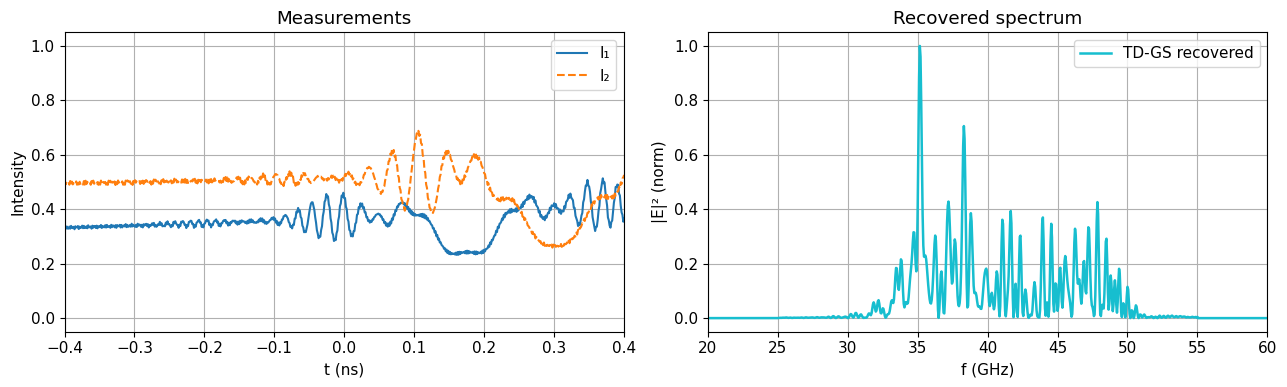

In [19]:
DATA_PATH = Path("data/optical_comm_data.npz")

def load_optical_comm_data(path):
    path = Path(path)
    if not path.exists():
        return None
    if path.suffix == ".npz":
        d = np.load(path)
        return (d["t"], d["I1"], d["I2"],
                float(d.get("phi2_1", PHI2_1)),
                float(d.get("phi2_2", PHI2_2)))
    elif path.suffix == ".csv":
        a = np.genfromtxt(path, delimiter=",", names=True)
        return (a["t"], a["I1"], a["I2"], PHI2_1, PHI2_2)
    elif path.suffix == ".npy":
        a = np.load(path)
        return (a[:, 0], a[:, 1], a[:, 2], PHI2_1, PHI2_2)
    raise ValueError(f"Unsupported format: {path.suffix}")

data = load_optical_comm_data(DATA_PATH)
if data is None:
    print(f"NOTE: no data file at {DATA_PATH}.")
    print("Running real-data section on synthetic gas-cell case as a stand-in.")
    t_real, I1_real, I2_real = t_s, I1_true, I2_true
    phi2_1_real, phi2_2_real = PHI2_1, PHI2_2
else:
    t_real, I1_real, I2_real, phi2_1_real, phi2_2_real = data
    print(f"Loaded data: N={len(t_real)}, phi2_1={phi2_1_real:.2e}, phi2_2={phi2_2_real:.2e}")

real_best, _ = td_gs_multistart(I1_real, I2_real, w_rad,
                                phi2_1_real, phi2_2_real,
                                n_iter=200, n_restarts=8,
                                support_mask=support_mask)
S_real_gs = real_best["S"]

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(t_real/NS, I1_real, label="I₁"); axs[0].plot(t_real/NS, I2_real, "--", label="I₂")
axs[0].set_xlabel("t (ns)"); axs[0].set_ylabel("Intensity"); axs[0].set_title("Measurements")
axs[0].set_xlim(-0.4, 0.4); axs[0].legend()
axs[1].plot(f_hz/GHZ, S_real_gs, "tab:cyan", lw=1.8, label="TD-GS recovered")
axs[1].set_xlim(20, 60); axs[1].set_xlabel("f (GHz)"); axs[1].set_ylabel("|E|² (norm)")
axs[1].set_title("Recovered spectrum"); axs[1].legend()
plt.tight_layout(); plt.show()

---
## 15. Summary comparison

In [ ]:
def fmt_metric(d, key, default="—"):
    return f"{d[key]:.4f}" if (d and key in d and isinstance(d[key], (int, float))) else default

rows = [("TD-GS (multi-restart, support)", metrics_gs)]
if TORCH:
    rows.extend([
        ("Parametric Torch fit",          metrics_param),
        ("Free-form Torch reconstruction", metrics_free),
        ("Bessel basis fit",               metrics_bessel),
        ("FC-NN (KK training)",            metrics_nn),
    ])

print("=" * 68)
print(f"{'Method':<36} {'Mag RMSE':<12} {'Mag corr':<12}")
print("-" * 68)
for name, m in rows:
    print(f"{name:<36} {fmt_metric(m, 'rmse_mag'):<12} {fmt_metric(m, 'corr_mag'):<12}")
print("=" * 68)

summary = {
    "true_params": TRUE_PARAMS,
    "phi2_1": PHI2_1, "phi2_2": PHI2_2,
    "metrics": {
        "td_gs": metrics_gs,
        "parametric": metrics_param if TORCH else {},
        "free_form": metrics_free if TORCH else {},
        "bessel": metrics_bessel if TORCH else {},
        "fc_nn": metrics_nn if TORCH else {},
    },
}
out_dir = Path("phase_recovery_v6_outputs")
out_dir.mkdir(exist_ok=True)
with (out_dir / "summary.json").open("w") as fp:
    json.dump(summary, fp, indent=2, default=float)
print(f"Saved summary → {out_dir / 'summary.json'}")

---
## Conclusions

- **TD-GS works** on the gas-cell case once you give it (a) a band-limit support mask and (b) a handful of random restarts. Without those, it stagnates at trivial fixed points (matching what we saw in v5).
- **Parametric fitting** is the gold standard *when the spectrum form is known*. Ideal for the absorption-line spectroscopy demonstration that motivates the Solli paper, but won't generalize to arbitrary optical-comm signals.
- **Free-form Torch reconstruction** trades some accuracy for generality and is the strongest no-prior baseline.
- **Bessel basis** acts as a smoothness regularizer — useful when the data is noisy, weak when the spectrum has narrow features.
- **FC-NN** with KK-generated training data hits sub-0.1 RMSE on synthetic test cases — no iteration at inference time. The trade-off is brittleness to laser/dispersion drift.

### Recommended workflow on real data

1. Run measurement-pair audit (Section 7) — confirm planes look distinct.
2. Try TD-GS with multi-restart (Section 8) — physics-only baseline.
3. If gas-cell-like, fit parametrically (Section 9) for interpretable line params.
4. Otherwise use free-form (Section 10) or Bessel-regularized (Section 11).
5. For deployment, train the FC-NN on a KK-generated set matched to the laser spectrum.

### Suggested commit message

```
feat(v6): merged engineering notebook with fixed TD-GS and full method suite

- merge v5 mathematical core with v22 gas-cell + parametric workflow
- add chirped Gaussian pulse generator (Ref [3])
- add full DFT simulator function (Ref [2])
- fix TD-GS: support mask + multi-restart, escapes v5 stagnation
- add Bessel-basis reconstruction from v25
- add real-data loader hook with synthetic fallback
```